<a href="https://colab.research.google.com/github/Nois12/AIFFEL_quest_rs/blob/main/GoingDeeper/Gd09/Stable_Diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stable diffusion project

### 프로젝트 흐름

```
패키지 설치
  │
라이브러리 불러오기 / 공통 유틸
  │
하이퍼파라미터 CFG 정리
  │
그래프 한글 폰트 설정 + CLIP 평가 도구 준비 (ClipScorer)
  │
Part 1. 잠재적 표현 관찰
  ├─ 프롬프트 A, B → 텍스트 인코더 임베딩 (77 × 768)
  ├─ 선형 보간 (α = 0 ~ 1, 9단계) + 초기 노이즈 고정 → 이미지 생성
  └─ 보간 이미지 격자 + CLIP 유사도 곡선 (A/B 교차 지점 확인)
  │
Part 2. Dreambooth 미세조정
  ├─ Instance 이미지 5장 준비 → train 4장 / valid 1장 분리
  ├─ 원본 SD 로 기준 이미지 생성 (sks dog + 새 상황 4가지)
  │    └─ 식별자 없는 '평범한 개' 이미지도 생성 → 평가 기준선
  ├─ train_dreambooth.py 학습 (prior preservation, class 이미지 100장 자동 생성, 400 스텝, lr 5e-6)
  ├─ class 이미지 저장 확인 + loss 곡선
  └─ 학습된 모델로 같은 프롬프트 생성 → 원본 vs Dreambooth 비교 격자
  │
Dreambooth 정량 평가 (CLIP)
  ├─ CLIP-I (valid / train) : 학습 대상과의 유사도, 외웠는지 확인
  ├─ CLIP-T : 프롬프트 반영도
  └─ 기준선(평범한 개, 같은 상황)과 비교 → 지표 막대그래프
  │
Part 3. Checkpoint + LoRA
  ├─ Checkpoint(hellofantasytime_v1.22) + LoRA(CivitAI) 다운로드
  ├─ LoRA 파일 형식 확인 (key 이름으로 표준 LoRA 여부 판별)
  ├─ diffusers 로더(load_lora_weights) 실패 (IndexError)
  │    └─ ManualLoRA 로 대체 : W' = W + s·(α/r)·BA 를 직접 계산해 적용
  │         (텍스트 인코더 레이어 이름 별칭 추가 → 264개 레이어 모두 대응)
  └─ LoRA 세기(0.0 / 0.4 / 0.8 / 1.2)별 이미지 생성 → 격자 비교
  │
결과 분석 (Part 1 / 2 / 3 결과 해석 작성)
```

## 환경 설정

In [ ]:
# 패키지 설치
!pip install -q -U diffusers transformers accelerate peft ftfy tensorboard bitsandbytes safetensors
!pip uninstall -y -q torchao   # LoRA 로드 시 충돌 방지
# import 오류가 나면 런타임을 재시작한 뒤 다시 실행

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 138.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.3/394.3 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 82.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 164.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 74.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 44.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.2 which is incompatible.
tensorflow 2.20.0 requires tensorboard~=2.20.0, but you have tensorboard 2.21.0 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.2

### 하이퍼파라미터 · 경로 · 시드

In [ ]:
import gc, math, random, shlex, shutil, urllib.request
from dataclasses import dataclass, field
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from tqdm.auto import tqdm
from diffusers import DPMSolverMultistepScheduler, StableDiffusionPipeline
from transformers import CLIPImageProcessor, CLIPTokenizer, CLIPTextModelWithProjection, CLIPVisionModelWithProjection

assert torch.cuda.is_available(), "GPU 런타임이 필요합니다. [런타임 > 런타임 유형 변경] 에서 GPU 를 선택하세요."


@dataclass
class CFG:
    # ---------- 공통 ----------
    seed: int = 42
    base_model: str = "CompVis/stable-diffusion-v1-4"
    clip_model: str = "openai/clip-vit-base-patch32"   # 평가용
    device: str = "cuda"
    dtype: torch.dtype = torch.float16
    out_dir: str = "outputs"

    # ---------- Part 1: 잠재 보간 ----------
    prompt_a: str = "A watercolor painting of a Golden Retriever at the beach"
    prompt_b: str = "An architectural sketch of a skyscraper"
    interp_steps: int = 9            # 보간 지점 수
    interp_batch: int = 3            # 한 번에 생성할 이미지 수
    interp_infer_steps: int = 25     # 디노이징 스텝 수
    guidance_scale: float = 7.5
    resolution: int = 512

    # ---------- Part 2: Dreambooth ----------
    identifier: str = "sks"          # 학습 대상을 가리키는 희귀 토큰
    class_word: str = "dog"          # 대상이 속한 범주
    data_dir: str = "data"
    valid_ratio: float = 0.2         # valid 로 쓸 비율
    num_class_images: int = 100      # class 이미지 수
    train_steps: int = 400           # 학습 스텝
    learning_rate: float = 5e-6
    train_batch_size: int = 1
    grad_accum_steps: int = 1
    prior_loss_weight: float = 1.0
    lr_scheduler: str = "constant"
    lr_warmup_steps: int = 0
    mixed_precision: str = "fp16"
    dreambooth_out: str = "dreambooth_out"
    # 테스트용 상황 (학습에 사용하지 않음)
    test_contexts: list = field(default_factory=lambda: [
        "swimming in a pool",
        "wearing a red santa hat",
        "sitting on a beach at sunset",
        "running in the snow",
    ])
    eval_seeds: tuple = (42, 43)     # 생성 시드
    eval_infer_steps: int = 50

    # ---------- Part 3: Checkpoint + LoRA ----------
    ckpt_model: str = "digiplay/hellofantasytime_v1.22"      # Hugging Face checkpoint
    lora_url: str = "https://civitai.com/api/download/models/116417"
    lora_path: str = "lora_weights/my_lora.safetensors"
    civitai_token: str = ""          # 다운로드가 막히면 API key 입력 또는 파일 직접 업로드
    taste_prompts: list = field(default_factory=lambda: [
        "masterpiece, high quality, a pink cat sitting in a bucket, bokeh background",
        "masterpiece, high quality, a small house in a fantasy forest, soft light",
    ])
    negative_prompt: str = "worst quality, low quality, blurry, text, logo, watermark, bad anatomy, deformed"
    lora_scales: tuple = (0.0, 0.4, 0.8, 1.2)   # 0.0 = LoRA 없음
    lora_infer_steps: int = 28
    lora_guidance: float = 7.0


cfg = CFG()
Path(cfg.out_dir).mkdir(exist_ok=True)


def set_seed(seed: int):
    # 난수 시드 고정
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def free_gpu():
    # GPU 메모리 정리
    gc.collect()
    torch.cuda.empty_cache()


def load_pipe(model_id):
    # 세이프티 체커는 끔 (정상 이미지를 검게 만드는 경우가 있음)
    pipe = StableDiffusionPipeline.from_pretrained(
        model_id, dtype=cfg.dtype, safety_checker=None, requires_safety_checker=False
    ).to(cfg.device)
    pipe.set_progress_bar_config(disable=True)
    return pipe


def show_grid(images, col_titles=None, row_titles=None, img_titles=None, ncols=None, cell=3.0, save=None, title=None):
    # 이미지를 격자로 보여주는 함수
    ncols = ncols or (len(col_titles) if col_titles else len(images))
    nrows = math.ceil(len(images) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(cell * ncols, cell * nrows), squeeze=False)
    for i, ax in enumerate(axes.flat):
        ax.axis("off")
        if i < len(images):
            ax.imshow(images[i])
            if img_titles:
                ax.set_title(img_titles[i], fontsize=9)
    if col_titles:
        for c, t in enumerate(col_titles):
            axes[0][c].set_title(t, fontsize=10)
    if row_titles:
        for r, t in enumerate(row_titles):
            axes[r][0].text(-0.05, 0.5, t, transform=axes[r][0].transAxes, ha="right", va="center", fontsize=9, wrap=True)
    if title:
        fig.suptitle(title, fontsize=12)
    plt.tight_layout()
    if save:
        fig.savefig(save, dpi=120, bbox_inches="tight")
    plt.show()


set_seed(cfg.seed)
print("설정 완료 | seed =", cfg.seed, "| GPU =", torch.cuda.get_device_name(0))

설정 완료 | seed = 42 | GPU = NVIDIA RTX PRO 6000 Blackwell Server Edition


### 그래프 한글 폰트 설정

In [ ]:
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
if not Path(font_path).exists():
    !apt-get -qq install -y fonts-nanum > /dev/null
if Path(font_path).exists():
    fm.fontManager.addfont(font_path)
    plt.rcParams["font.family"] = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams["axes.unicode_minus"] = False
else:
    print("한글 폰트를 찾지 못했습니다. 그래프 제목이 깨질 수 있습니다.")

### 평가 도구: CLIP 유사도

In [ ]:
class ClipScorer:
    # 이미지/텍스트를 CLIP 임베딩으로 변환
    def __init__(self, model_id, device):
        self.device = device
        self.processor = CLIPImageProcessor.from_pretrained(model_id)
        self.tokenizer = CLIPTokenizer.from_pretrained(model_id)
        self.vision = CLIPVisionModelWithProjection.from_pretrained(model_id).to(device).eval()
        self.text = CLIPTextModelWithProjection.from_pretrained(model_id).to(device).eval()

    @torch.no_grad()
    def image(self, images):
        pixel = self.processor(images=images, return_tensors="pt")["pixel_values"].to(self.device)
        emb = self.vision(pixel_values=pixel).image_embeds
        return torch.nn.functional.normalize(emb, dim=-1).cpu()

    @torch.no_grad()
    def text_emb(self, texts):
        tok = self.tokenizer(texts, padding=True, truncation=True, return_tensors="pt").to(self.device)
        emb = self.text(**tok).text_embeds
        return torch.nn.functional.normalize(emb, dim=-1).cpu()


scorer = ClipScorer(cfg.clip_model, cfg.device)

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

...

[transformers] CLIPVisionModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.bias     | UNEXPECTED |  | 
text_model.final_layer_norm.weight                           | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
text_model.encoder.layers.{0

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] CLIPTextModelWithProjection LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.v_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
visual_projection.weight                                       | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
vision_model.pre_layrnorm.weight                               | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
vision_m

---
## **Part 1. 잠재적 표현의 변화가 출력에 미치는 영향 관찰**

In [ ]:
pipe = load_pipe(cfg.base_model)


@torch.no_grad()
def encode_prompt(pipe, prompt):
    # 프롬프트를 (77, 768) 임베딩으로 변환
    ids = pipe.tokenizer(
        prompt, padding="max_length", max_length=pipe.tokenizer.model_max_length,
        truncation=True, return_tensors="pt",
    ).input_ids.to(cfg.device)
    return pipe.text_encoder(ids).last_hidden_state.squeeze(0)


emb_a = encode_prompt(pipe, cfg.prompt_a)
emb_b = encode_prompt(pipe, cfg.prompt_b)
print("임베딩 shape:", tuple(emb_a.shape))

# 선형 보간
alphas = torch.linspace(0, 1, cfg.interp_steps)
interp_emb = torch.stack([(1 - a) * emb_a + a * emb_b for a in alphas.tolist()])
print("보간 임베딩 shape:", tuple(interp_emb.shape))

# 모든 이미지가 같이 쓸 초기 노이즈
latent_size = cfg.resolution // pipe.vae_scale_factor
gen = torch.Generator(device=cfg.device).manual_seed(cfg.seed)
fixed_noise = torch.randn((1, pipe.unet.config.in_channels, latent_size, latent_size),
                          generator=gen, device=cfg.device, dtype=cfg.dtype)

interp_images = []
for chunk in tqdm(torch.split(interp_emb, cfg.interp_batch), desc="보간 이미지 생성"):
    n = chunk.shape[0]
    out = pipe(
        prompt_embeds=chunk.to(cfg.dtype),
        latents=fixed_noise.expand(n, -1, -1, -1).contiguous(),
        num_inference_steps=cfg.interp_infer_steps,
        guidance_scale=cfg.guidance_scale,
    )
    interp_images += out.images

model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 14 files:   0%|          | 0/14 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

임베딩 shape: (77, 768)
보간 임베딩 shape: (9, 77, 768)


보간 이미지 생성:   0%|          | 0/3 [00:00<?, ?it/s]

### 시각화: 보간 결과 (왼쪽 = 프롬프트 A, 오른쪽 = 프롬프트 B)

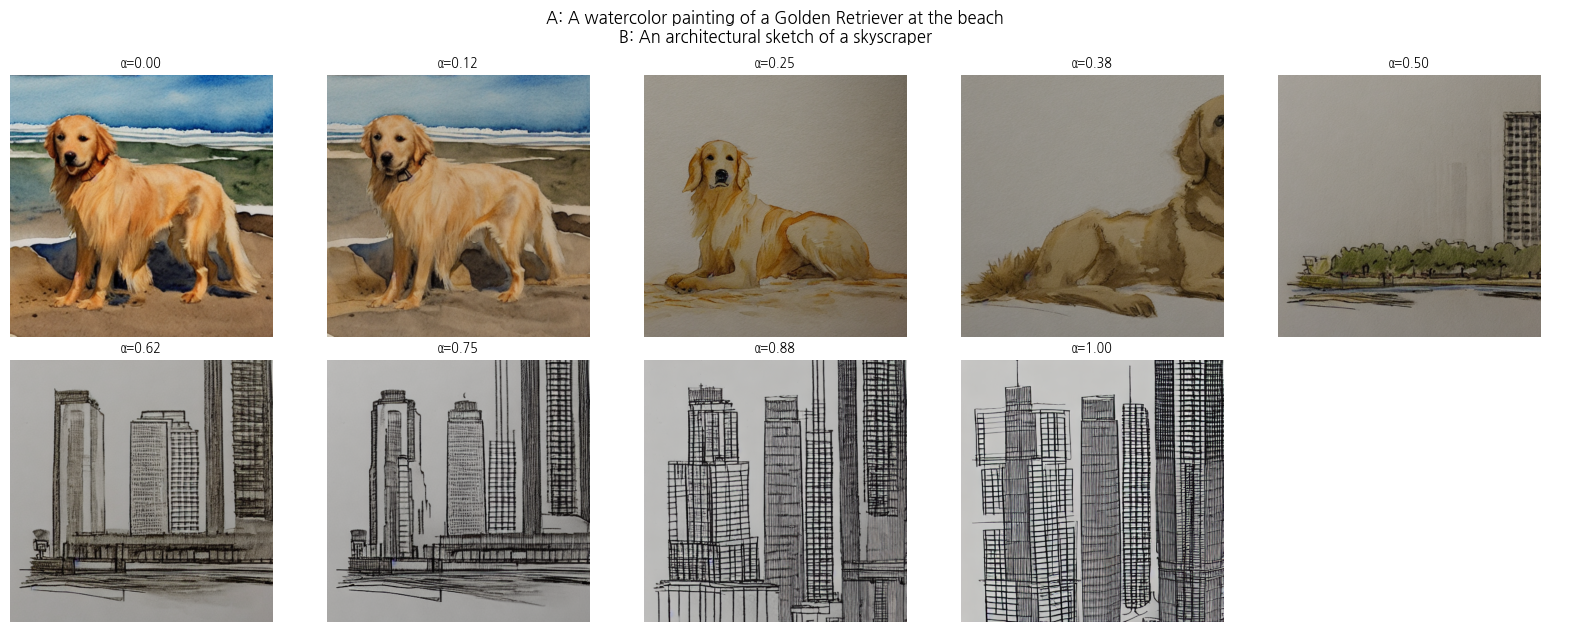

In [ ]:
show_grid(
    interp_images,
    img_titles=[f"α={a:.2f}" for a in alphas.tolist()],
    ncols=5, cell=3.2,
    save=f"{cfg.out_dir}/part1_interpolation.png",
    title=f"A: {cfg.prompt_a}\nB: {cfg.prompt_b}",
)

### 시각화: 프롬프트 A / B 와의 유사도

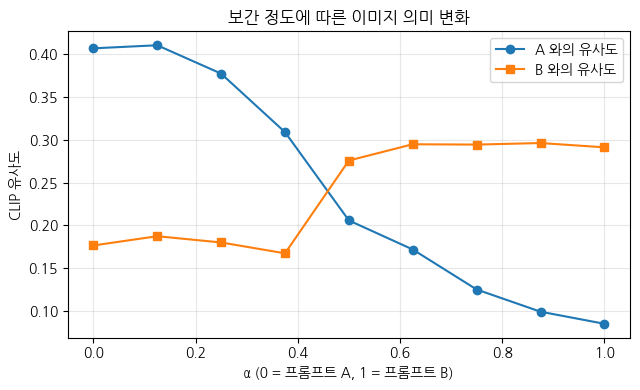

α = 0.50 부터 프롬프트 B 쪽이 더 가깝게 인식됩니다.


In [ ]:
img_feat = scorer.image(interp_images)                       # (N, 512)
txt_feat = scorer.text_emb([cfg.prompt_a, cfg.prompt_b])      # (2, 512)
sim = img_feat @ txt_feat.T                                   # (N, 2)
sim_a, sim_b = sim[:, 0].numpy(), sim[:, 1].numpy()

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(alphas.numpy(), sim_a, "o-", label="A 와의 유사도")
ax.plot(alphas.numpy(), sim_b, "s-", label="B 와의 유사도")
ax.set_xlabel("α (0 = 프롬프트 A, 1 = 프롬프트 B)")
ax.set_ylabel("CLIP 유사도")
ax.set_title("보간 정도에 따른 이미지 의미 변화")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig(f"{cfg.out_dir}/part1_clip_similarity.png", dpi=120)
plt.show()

# B 가 처음으로 더 가까워지는 지점
cross = np.where(sim_b > sim_a)[0]
if len(cross):
    print(f"α = {alphas[cross[0]].item():.2f} 부터 프롬프트 B 쪽이 더 가깝게 인식됩니다.")
else:
    print("모든 구간에서 프롬프트 A 쪽이 더 가깝게 인식되었습니다.")

In [ ]:
# GPU 메모리 정리
del pipe
free_gpu()

---
## **Part 2. Dreambooth 미세조정**

### 데이터 준비: Instance 이미지를 train / valid 로 분리

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

전체 5장 → train 4장 / valid 1장


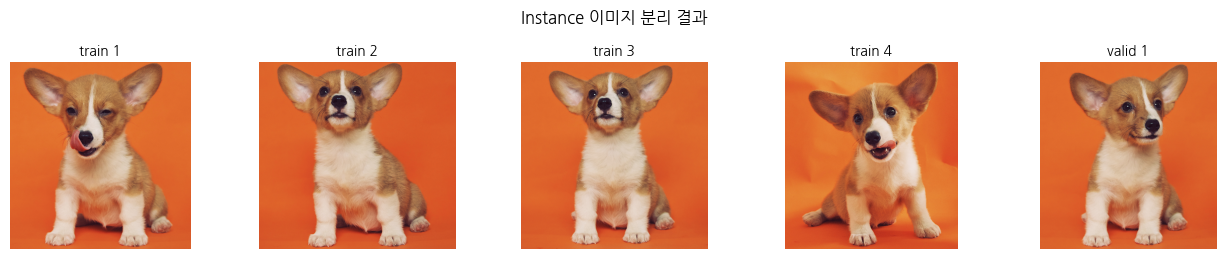

In [ ]:
DATA = Path(cfg.data_dir)
raw_dir, train_dir, valid_dir, class_dir = (DATA / n for n in ["raw_instance", "instance_train", "instance_valid", "class"])
IMG_EXT = {".jpg", ".jpeg", ".png", ".webp"}


def list_images(folder):
    return sorted(p for p in Path(folder).glob("*") if p.suffix.lower() in IMG_EXT)


def load_images(paths):
    return [Image.open(p).convert("RGB") for p in paths]


# 내 이미지가 없으면 예제 강아지 이미지 다운로드
raw_dir.mkdir(parents=True, exist_ok=True)
if not list_images(raw_dir):
    from huggingface_hub import snapshot_download
    snapshot_download("diffusers/dog-example", local_dir=raw_dir, repo_type="dataset", ignore_patterns=".gitattributes")
    shutil.rmtree(raw_dir / ".cache", ignore_errors=True)

# train / valid 분리
files = list_images(raw_dir)
assert len(files) >= 3, "instance 이미지가 최소 3장 필요합니다."
random.Random(cfg.seed).shuffle(files)
n_valid = max(1, round(len(files) * cfg.valid_ratio))
valid_files, train_files = files[:n_valid], files[n_valid:]

for folder, subset in [(train_dir, train_files), (valid_dir, valid_files)]:
    shutil.rmtree(folder, ignore_errors=True)
    folder.mkdir(parents=True)
    for f in subset:
        shutil.copy(f, folder / f.name)

print(f"전체 {len(files)}장 → train {len(train_files)}장 / valid {len(valid_files)}장")
show_grid(load_images(train_files) + load_images(valid_files),
          col_titles=[f"train {i+1}" for i in range(len(train_files))] + [f"valid {i+1}" for i in range(len(valid_files))],
          cell=2.6, save=f"{cfg.out_dir}/part2_split.png", title="Instance 이미지 분리 결과")

### 학습 전 기준(Baseline) 만들기

In [ ]:
instance_prompt = f"a photo of {cfg.identifier} {cfg.class_word}"
class_prompt = f"a photo of {cfg.class_word}"

# 테스트 프롬프트 / CLIP-T 계산용 프롬프트(식별자 제거)
test_prompts = [f"{instance_prompt} {c}" for c in cfg.test_contexts]
text_refs = [f"{class_prompt} {c}" for c in cfg.test_contexts]


def generate(pipe, prompts, seeds):
    # 프롬프트 × 시드 조합으로 이미지 생성
    images = []
    for p in tqdm(prompts, desc="생성"):
        for s in seeds:
            g = torch.Generator(device=cfg.device).manual_seed(s)
            images.append(pipe(p, num_inference_steps=cfg.eval_infer_steps,
                               guidance_scale=cfg.guidance_scale, generator=g).images[0])
    return images


pipe = load_pipe(cfg.base_model)
base_images = generate(pipe, test_prompts, cfg.eval_seeds)
# 기준선: 식별자 없이 같은 상황으로 생성
class_ctx_images = generate(pipe, text_refs, cfg.eval_seeds)
del pipe
free_gpu()

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

생성:   0%|          | 0/4 [00:00<?, ?it/s]

생성:   0%|          | 0/4 [00:00<?, ?it/s]

### 하이퍼파라미터 정리 & 학습 실행

In [ ]:
# 학습 스크립트 다운로드 (diffusers 버전에 맞춤)
import diffusers
script = Path("train_dreambooth.py")
if not script.exists():
    base_url = "https://raw.githubusercontent.com/huggingface/diffusers/{}/examples/dreambooth/train_dreambooth.py"
    for ref in [f"v{diffusers.__version__}", "main"]:
        try:
            urllib.request.urlretrieve(base_url.format(ref), script)
            print("학습 스크립트 다운로드:", ref)
            break
        except Exception as e:
            print(f"{ref} 다운로드 실패 → 다음 후보 시도 ({e})")
assert script.exists(), "train_dreambooth.py 를 내려받지 못했습니다."

학습 스크립트 다운로드: v0.40.0


In [ ]:
# 학습 인자 구성
train_args = {
    "pretrained_model_name_or_path": cfg.base_model,
    "instance_data_dir": train_dir,          # train 만 사용
    "class_data_dir": class_dir,
    "output_dir": cfg.dreambooth_out,
    "instance_prompt": instance_prompt,
    "class_prompt": class_prompt,
    "resolution": cfg.resolution,
    "train_batch_size": cfg.train_batch_size,
    "gradient_accumulation_steps": cfg.grad_accum_steps,
    "learning_rate": cfg.learning_rate,
    "lr_scheduler": cfg.lr_scheduler,
    "lr_warmup_steps": cfg.lr_warmup_steps,
    "num_class_images": cfg.num_class_images,
    "prior_loss_weight": cfg.prior_loss_weight,
    "max_train_steps": cfg.train_steps,
    "mixed_precision": cfg.mixed_precision,
    "sample_batch_size": 4,                   # class 이미지 생성 배치 크기
    "checkpointing_steps": 10**9,             # 중간 저장 안 함
    "seed": cfg.seed,
}
train_flags = ["with_prior_preservation", "gradient_checkpointing", "use_8bit_adam", "set_grads_to_none"]

cmd = "accelerate launch " + shlex.quote(str(script)) + " " \
      + " ".join(f"--{k}={shlex.quote(str(v))}" for k, v in train_args.items()) + " " \
      + " ".join(f"--{f}" for f in train_flags)
print(cmd)

accelerate launch train_dreambooth.py --pretrained_model_name_or_path=CompVis/stable-diffusion-v1-4 --instance_data_dir=data/instance_train --class_data_dir=data/class --output_dir=dreambooth_out --instance_prompt='a photo of sks dog' --class_prompt='a photo of dog' --resolution=512 --train_batch_size=1 --gradient_accumulation_steps=1 --learning_rate=5e-06 --lr_scheduler=constant --lr_warmup_steps=0 --num_class_images=100 --prior_loss_weight=1.0 --max_train_steps=400 --mixed_precision=fp16 --sample_batch_size=4 --checkpointing_steps=1000000000 --seed=42 --with_prior_preservation --gradient_checkpointing --use_8bit_adam --set_grads_to_none


In [ ]:
# 학습 시작 (class 이미지 생성 포함, 시간이 걸림)
!{cmd}
print("학습 완료!")

The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
09/21/2026 06:04:55 - INFO - __main__ - [RANK 0] Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16

/usr/local/lib/python3.13/dist-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)
09/21/2026 06:04:56 - INFO - httpx - HTTP Request: GET https://huggingface.co/api/models/CompVis/stable-diffusion-v1-4 "HTTP/1.1 200 OK"
09/21/2026 06:04:56 - INFO -

### 학습 결과 확인: class 이미지 & loss 곡선

class 이미지: 100장 저장됨 (data/class)


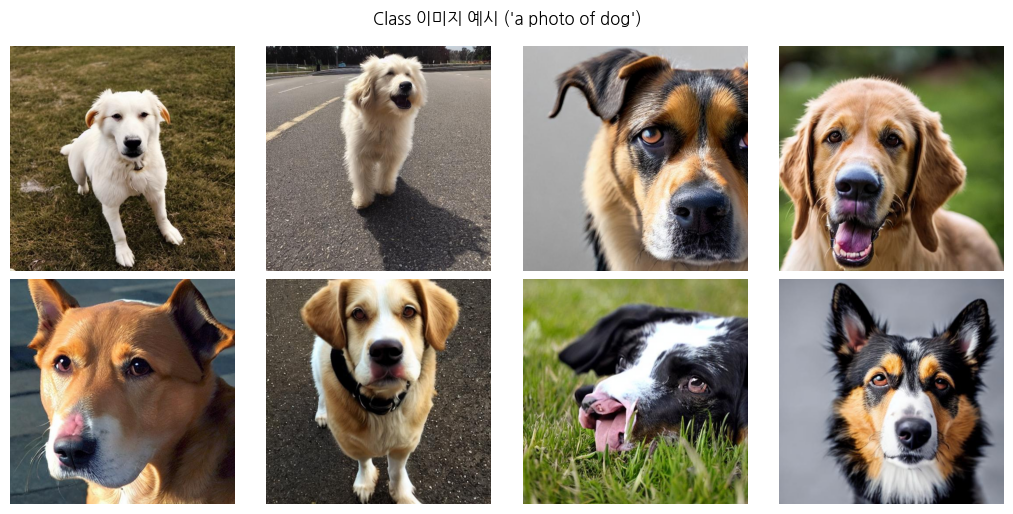

In [ ]:
class_files = list_images(class_dir)
print(f"class 이미지: {len(class_files)}장 저장됨 ({class_dir})")
assert len(class_files) >= 100, "class 이미지가 100장 미만입니다. num_class_images 를 확인하세요."
show_grid(load_images(class_files[:8]), ncols=4, cell=2.6, save=f"{cfg.out_dir}/part2_class_samples.png",
          title=f"Class 이미지 예시 ('{class_prompt}')")

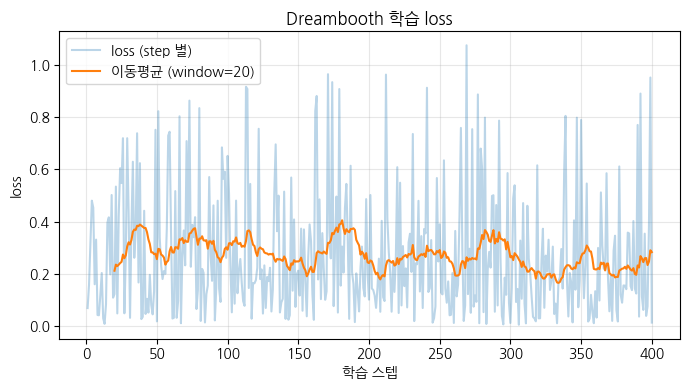

In [ ]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

event_files = sorted(Path(cfg.dreambooth_out).rglob("events.out.tfevents.*"))
assert event_files, "tensorboard 로그가 없습니다. 학습이 정상 종료되었는지 확인하세요."
ea = EventAccumulator(str(event_files[-1].parent))
ea.Reload()
scalars = ea.Scalars("loss")
steps = np.array([s.step for s in scalars])
loss = np.array([s.value for s in scalars])
window = max(1, min(20, len(loss) // 5))
smooth = np.convolve(loss, np.ones(window) / window, mode="valid")   # 이동평균

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(steps, loss, alpha=0.3, label="loss (step 별)")
ax.plot(steps[window - 1:], smooth, label=f"이동평균 (window={window})")
ax.set_xlabel("학습 스텝")
ax.set_ylabel("loss")
ax.set_title("Dreambooth 학습 loss")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
fig.savefig(f"{cfg.out_dir}/part2_loss.png", dpi=120)
plt.show()

### 학습된 모델로 생성 & 평가 (원본 SD vs Dreambooth)

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

생성:   0%|          | 0/4 [00:00<?, ?it/s]

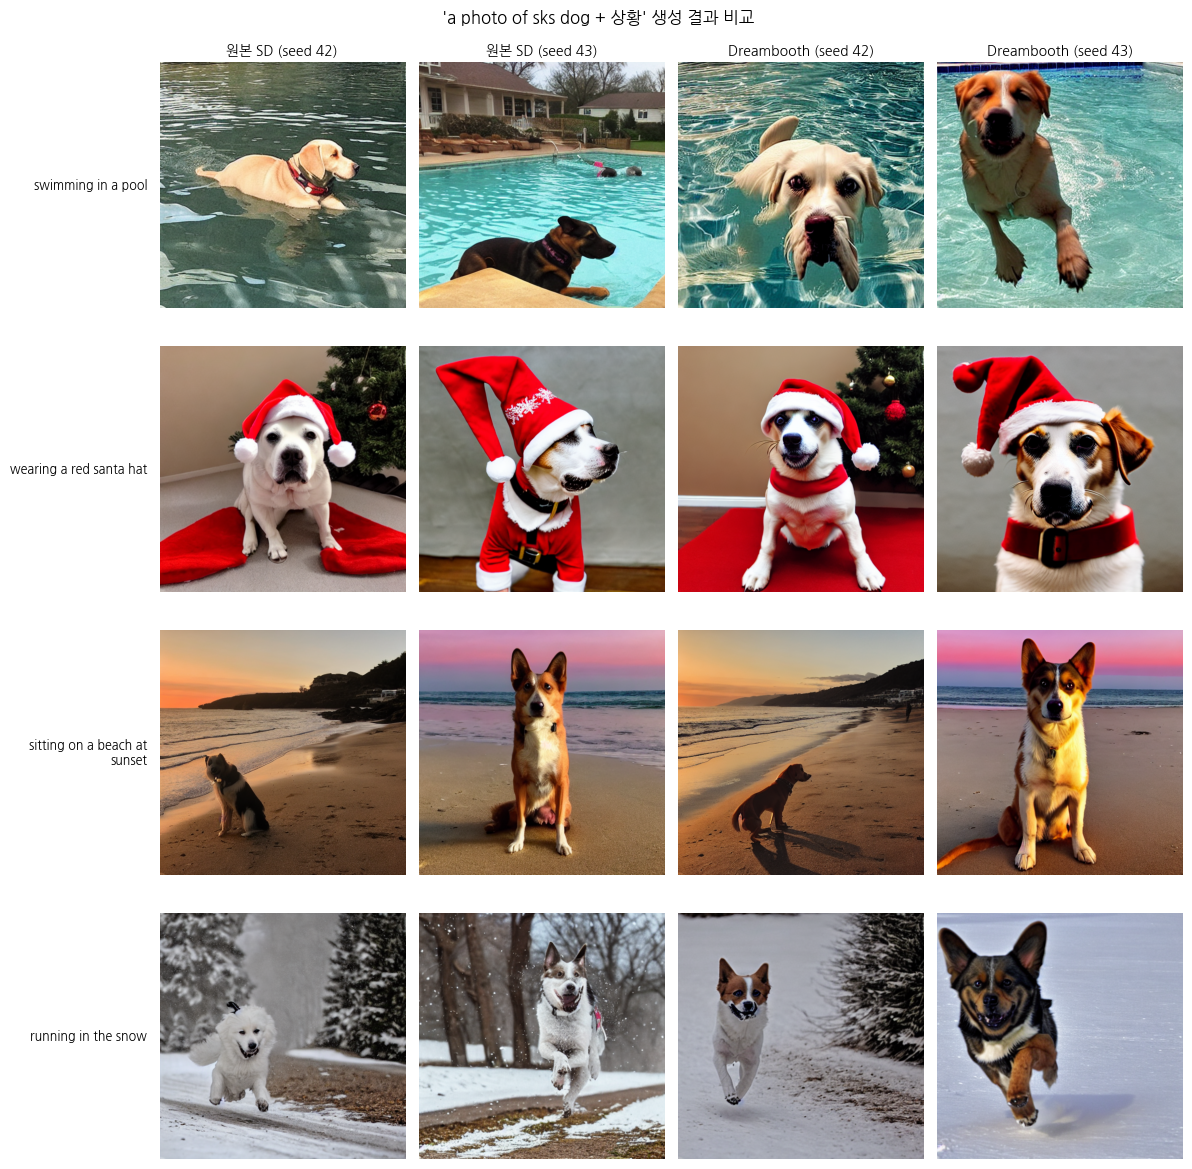

In [ ]:
ft_pipe = load_pipe(cfg.dreambooth_out)      # 학습된 파이프라인
ft_images = generate(ft_pipe, test_prompts, cfg.eval_seeds)

# instance prompt 만으로 이미지 1장 생성
g = torch.Generator(device=cfg.device).manual_seed(cfg.seed)
basic_image = ft_pipe(instance_prompt, num_inference_steps=cfg.eval_infer_steps,
                      guidance_scale=cfg.guidance_scale, generator=g).images[0]
basic_image.save(f"{cfg.out_dir}/part2_instance_prompt.png")
del ft_pipe
free_gpu()

# 비교 시각화 (행: 테스트 프롬프트, 열: 원본 / 학습 후)
n_seed = len(cfg.eval_seeds)
grid = []
for i in range(len(test_prompts)):
    grid += base_images[i * n_seed:(i + 1) * n_seed] + ft_images[i * n_seed:(i + 1) * n_seed]
show_grid(
    grid,
    col_titles=[f"원본 SD (seed {s})" for s in cfg.eval_seeds] + [f"Dreambooth (seed {s})" for s in cfg.eval_seeds],
    row_titles=[c for c in cfg.test_contexts],
    cell=3.0, save=f"{cfg.out_dir}/part2_base_vs_dreambooth.png",
    title=f"'{instance_prompt} + 상황' 생성 결과 비교",
)

### 정량 평가 (CLIP)

지표                   원본 SD  Dreambooth
CLIP-I (valid)       0.690       0.734
CLIP-I (train)       0.696       0.745
CLIP-T               0.329       0.326
기준선(일반 개)            0.722


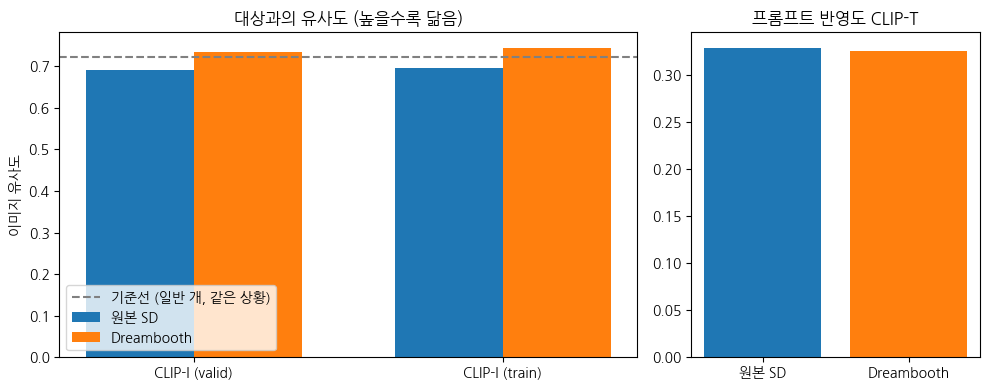

In [ ]:
f_train = scorer.image(load_images(train_files))
f_valid = scorer.image(load_images(valid_files))
f_class_ctx = scorer.image(class_ctx_images)
t_feat = scorer.text_emb([t for t in text_refs for _ in cfg.eval_seeds])   # 이미지 순서에 맞춰 반복


def evaluate(images):
    f = scorer.image(images)
    return {
        "CLIP-I (valid)": (f @ f_valid.T).mean().item(),
        "CLIP-I (train)": (f @ f_train.T).mean().item(),
        "CLIP-T": (f * t_feat).sum(-1).mean().item(),
    }


res_base, res_ft = evaluate(base_images), evaluate(ft_images)
baseline = (f_class_ctx @ f_valid.T).mean().item()

print(f"{'지표':<16}{'원본 SD':>10}{'Dreambooth':>12}")
for k in res_base:
    print(f"{k:<16}{res_base[k]:>10.3f}{res_ft[k]:>12.3f}")
print(f"{'기준선(일반 개)':<16}{baseline:>10.3f}")

# 지표 비교 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4), gridspec_kw={"width_ratios": [2, 1]})
keys_i = ["CLIP-I (valid)", "CLIP-I (train)"]
x = np.arange(len(keys_i)); w = 0.35
axes[0].bar(x - w / 2, [res_base[k] for k in keys_i], w, label="원본 SD")
axes[0].bar(x + w / 2, [res_ft[k] for k in keys_i], w, label="Dreambooth")
axes[0].axhline(baseline, color="gray", ls="--", label="기준선 (일반 개, 같은 상황)")
axes[0].set_xticks(x); axes[0].set_xticklabels(keys_i)
axes[0].set_ylabel("이미지 유사도"); axes[0].set_title("대상과의 유사도 (높을수록 닮음)"); axes[0].legend()
axes[1].bar(["원본 SD", "Dreambooth"], [res_base["CLIP-T"], res_ft["CLIP-T"]], color=["C0", "C1"])
axes[1].set_title("프롬프트 반영도 CLIP-T")
plt.tight_layout()
fig.savefig(f"{cfg.out_dir}/part2_metrics.png", dpi=120)
plt.show()

---
## **Part 3. 나만의 취향: Checkpoint + LoRA**

In [ ]:
def download(url, dest, token=""):
    dest = Path(dest)
    dest.parent.mkdir(parents=True, exist_ok=True)
    if dest.exists() and dest.stat().st_size > 0:
        print("이미 파일이 있습니다:", dest)
        return dest
    headers = {"User-Agent": "Mozilla/5.0"}
    if token:
        headers["Authorization"] = f"Bearer {token}"
    try:
        with urllib.request.urlopen(urllib.request.Request(url, headers=headers)) as r, open(dest, "wb") as f:
            shutil.copyfileobj(r, f)
    except Exception as e:
        dest.unlink(missing_ok=True)
        raise RuntimeError(
            f"다운로드 실패: {e}\n→ 브라우저에서 직접 받아 '{dest}' 경로에 업로드하거나, CFG.civitai_token 에 API key 를 넣어주세요."
        )
    print(f"다운로드 완료: {dest} ({dest.stat().st_size / 1e6:.1f} MB)")
    return dest


lora_path = download(cfg.lora_url, cfg.lora_path, cfg.civitai_token)

다운로드 완료: lora_weights/my_lora.safetensors (151.1 MB)


### LoRA 파일 형식 확인

In [ ]:
from collections import Counter
from safetensors import safe_open


def inspect_lora(path):
    # 가중치 이름으로 LoRA 형식 확인
    with safe_open(str(path), framework="pt") as f:
        keys = list(f.keys())
    has = lambda *pats: any(p in k for k in keys for p in pats)
    prefix = Counter("_".join(k.split("_")[:2]) for k in keys)   # 예: lora_unet, lora_te
    return {
        "key 개수": len(keys),
        "key 접두어 분포": dict(prefix.most_common(4)),
        "key 예시": keys[:2],
        "표준 LoRA (lora_down/up 또는 lora_A/B)": has("lora_down", "lora_up", "lora_A", "lora_B"),
        "LoHa (hada_)": has("hada_"),
        "LoKr (lokr_)": has("lokr_"),
        "SDXL 계열 (lora_te2)": has("lora_te2"),
    }


info = inspect_lora(lora_path)
for k, v in info.items():
    print(f"{k}: {v}")

if not info["표준 LoRA (lora_down/up 또는 lora_A/B)"] or info["LoHa (hada_)"] or info["LoKr (lokr_)"] or info["SDXL 계열 (lora_te2)"]:
    raise RuntimeError(
        "이 파일은 SD 1.5 용 표준 LoRA 가 아닙니다 (LyCORIS/SDXL 등).\n"
        "→ CivitAI 에서 Model types = 'LoRA', Base model = 'SD 1.5' 로 필터링해 다른 파일을 고르고,\n"
        "  다운로드 링크의 모델 버전 번호를 CFG.lora_url 에 넣은 뒤 lora_weights/ 폴더의 기존 파일을 지우고 다시 실행하세요."
    )
print("→ diffusers 로 불러올 수 있는 형식입니다.")

key 개수: 792
key 접두어 분포: {'lora_unet': 576, 'lora_te': 216}
key 예시: ['lora_te_text_model_encoder_layers_0_mlp_fc1.alpha', 'lora_te_text_model_encoder_layers_0_mlp_fc1.lora_down.weight']
표준 LoRA (lora_down/up 또는 lora_A/B): True
LoHa (hada_): False
LoKr (lokr_): False
SDXL 계열 (lora_te2): False
→ diffusers 로 불러올 수 있는 형식입니다.


### 파이프라인 구성 + LoRA 적용

In [ ]:
from safetensors.torch import load_file


class ManualLoRA:
    # LoRA 를 가중치에 직접 더함: W' = W + scale * (alpha / rank) * (up @ down)
    def __init__(self, pipe, path):
        state = load_file(str(path))

        # LoRA 이름 → 모델 레이어 대응표
        targets = {}
        for prefix, model in [("lora_unet", pipe.unet), ("lora_te", pipe.text_encoder)]:
            for name, module in model.named_modules():
                if isinstance(module, (torch.nn.Linear, torch.nn.Conv2d)):
                    targets[f"{prefix}_{name.replace('.', '_')}"] = module
                    # 최신 transformers 는 'text_model.' 이 빠져 있어 별칭 추가
                    if prefix == "lora_te" and not name.startswith("text_model"):
                        targets[f"lora_te_text_model_{name.replace('.', '_')}"] = module

        self.items = []      # (레이어, 원래 가중치, 변화량)
        skipped = 0
        for key in state:
            if not key.endswith(".lora_down.weight"):
                continue
            base = key[: -len(".lora_down.weight")]
            module = targets.get(base)
            if module is None:
                skipped += 1
                continue
            down = state[key].float().to(pipe.device)                    # (rank, in, ...)
            up = state[base + ".lora_up.weight"].float().to(pipe.device)  # (out, rank, ...)
            rank = down.shape[0]
            alpha = state[base + ".alpha"].item() if (base + ".alpha") in state else rank
            delta = (up.flatten(1) @ down.flatten(1)) * (alpha / rank)
            delta = delta.reshape(module.weight.shape).to(module.weight.dtype)
            self.items.append((module, module.weight.data.clone(), delta))

        if not self.items:
            raise RuntimeError(f"적용할 수 있는 LoRA 레이어가 없습니다. key 예시: {list(state)[:3]}")
        print(f"직접 합성 준비 완료: {len(self.items)}개 레이어 (대응 실패 {skipped}개)")

    @torch.no_grad()
    def apply(self, scale):
        # 항상 원래 가중치 + scale × 변화량 으로 계산
        for module, orig, delta in self.items:
            module.weight.data.copy_((orig.float() + scale * delta.float()).to(orig.dtype))


pipe = load_pipe(cfg.ckpt_model)
pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)

try:
    pipe.load_lora_weights(str(lora_path.parent), weight_name=lora_path.name, adapter_name="taste")
    lora_mode = "diffusers"
except Exception as e:
    print(f"diffusers 로더 실패 ({type(e).__name__}: {e}) → 직접 합성 방식으로 전환합니다")
    del pipe
    free_gpu()
    pipe = load_pipe(cfg.ckpt_model)          # 깨끗하게 다시 생성
    pipe.scheduler = DPMSolverMultistepScheduler.from_config(pipe.scheduler.config)
    manual_lora = ManualLoRA(pipe, lora_path)
    lora_mode = "manual"


def set_lora_scale(scale):
    if lora_mode == "diffusers":
        pipe.set_adapters(["taste"], adapter_weights=[scale])
    else:
        manual_lora.apply(scale)


print(f"파이프라인 준비 완료 | checkpoint: {cfg.ckpt_model} | LoRA 적용 방식: {lora_mode}")

model_index.json:   0%|          | 0.00/598 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


...

diffusers 로더 실패 (IndexError: list index out of range) → 직접 합성 방식으로 전환합니다


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

직접 합성 준비 완료: 264개 레이어 (대응 실패 0개)
파이프라인 준비 완료 | checkpoint: digiplay/hellofantasytime_v1.22 | LoRA 적용 방식: manual


### 생성 & 시각화: LoRA 세기에 따른 변화

프롬프트:   0%|          | 0/2 [00:00<?, ?it/s]

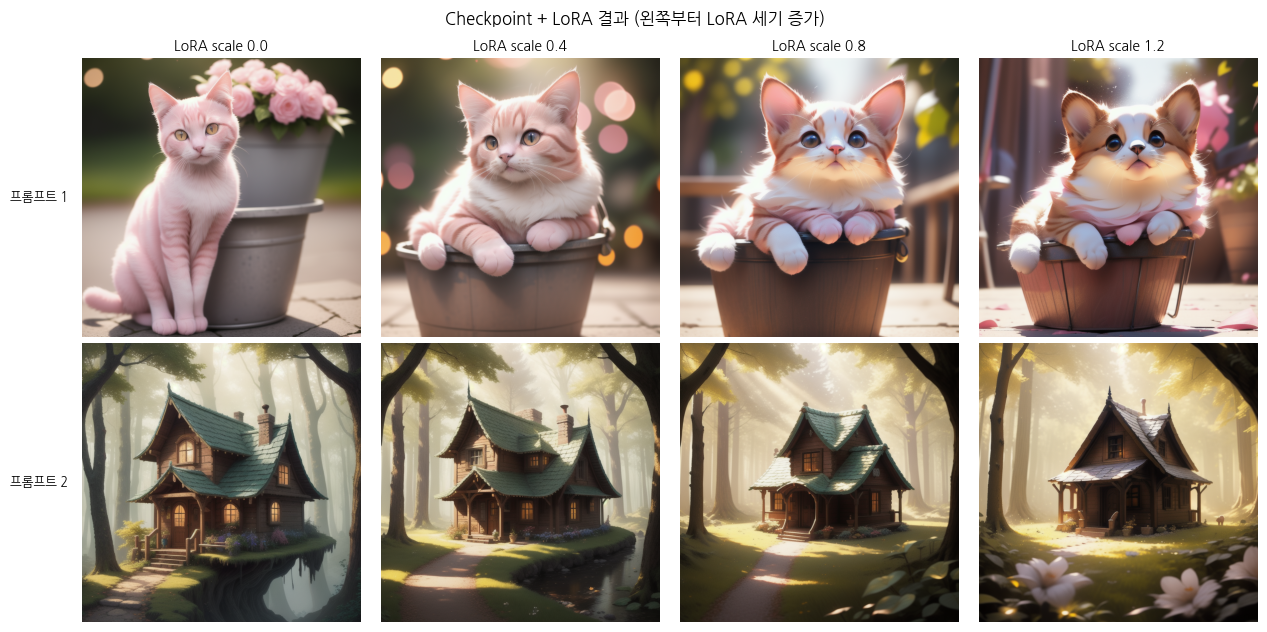

프롬프트 1: masterpiece, high quality, a pink cat sitting in a bucket, bokeh background
프롬프트 2: masterpiece, high quality, a small house in a fantasy forest, soft light


In [ ]:
taste_images = []
for prompt in tqdm(cfg.taste_prompts, desc="프롬프트"):
    for scale in cfg.lora_scales:
        set_lora_scale(scale)
        g = torch.Generator(device=cfg.device).manual_seed(cfg.seed)      # 시드는 동일, 세기만 변경
        taste_images.append(pipe(
            prompt=prompt, negative_prompt=cfg.negative_prompt,
            num_inference_steps=cfg.lora_infer_steps, guidance_scale=cfg.lora_guidance, generator=g,
        ).images[0])

show_grid(
    taste_images,
    col_titles=[f"LoRA scale {s}" for s in cfg.lora_scales],
    row_titles=[f"프롬프트 {i+1}" for i in range(len(cfg.taste_prompts))],
    cell=3.2, save=f"{cfg.out_dir}/part3_lora_scales.png",
    title="Checkpoint + LoRA 결과 (왼쪽부터 LoRA 세기 증가)",
)
for i, p in enumerate(cfg.taste_prompts):
    print(f"프롬프트 {i+1}: {p}")

In [ ]:
del pipe
free_gpu()
print("생성된 결과 파일:")
for p in sorted(Path(cfg.out_dir).glob("*")):
    print(" -", p)

생성된 결과 파일:
 - outputs/part1_clip_similarity.png
 - outputs/part1_interpolation.png
 - outputs/part2_base_vs_dreambooth.png
 - outputs/part2_class_samples.png
 - outputs/part2_instance_prompt.png
 - outputs/part2_loss.png
 - outputs/part2_metrics.png
 - outputs/part2_split.png
 - outputs/part3_lora_scales.png


### 결과 분석

**Part 1. 프롬프트 보간**
- 두 프롬프트 사이를 보간하자 이미지가 수채화 강아지에서 펜 스케치 고층 빌딩으로 바뀌었다. 강아지와 건물이 한 장면에 함께 나온 이미지는 없었다.
- 텍스트 임베딩은 선형으로 변했지만, 이미지의 의미 변화는 α = 0.38 ~ 0.50 구간에 집중된 계단형이었다. CLIP 유사도 곡선도 이 구간에서 교차했다.

**Part 2. Dreambooth**
- 학습 후 갈색·흰 털과 큰 귀가 보이는 이미지가 나타났지만, 모든 이미지가 학습 대상처럼 나오지는 않아 대상의 특징을 부분적으로 학습한 것으로 판단된다.
- 새로운 상황(수영, 산타 모자, 석양 해변, 눈)은 모두 반영되었고 CLIP-T 도 거의 변하지 않았다(0.329 → 0.326).
- CLIP-I(valid)는 0.690 → 0.734 로 올랐지만 기준선(0.722)보다 0.012 높은 정도이고, valid 와 train 의 차이(0.011)가 작아 학습 이미지를 외운 징후는 없었다.


**Part 3. Checkpoint + LoRA**
- diffusers 로더가 LoRA 파일을 읽지 못해 LoRA 수식을 직접 계산해 적용했고, 264개 레이어가 모두 대응되었다.
- LoRA 세기가 커질수록 LoRA 의 스타일(둥근 형태, 부드러운 빛)은 강해지고, 프롬프트의 색 지정(pink)과 세부 요소는 약해졌다.

## 회고
음...그냥 저냥 한것 같은데 오늘은 집중해서 프로젝트를 잘 수행하지 못한 점이 개인적으로 아쉬운점이고, 무난하게 진행한 것 같다..